## Dataframe 1 : Multi-class dataframe

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import confusion_matrix

from sklearn.model_selection import GridSearchCV 

from snowflake.ml.modeling.model_selection import GridSearchCV


from sklearn.model_selection import train_test_split


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import metrics
from sklearn import preprocessing

import matplotlib.pyplot as plt

# from sklearn.tree import DecisionTreeClassifier
# from sklearn.tree import export_graphviz
 
# from IPython.display import Image 
# #!pip install pydotplus
# import pydotplus

# import graphviz
# from six import StringIO

# import six
# import sys
# sys.modules['sklearn.externals.six'] = six
# from sklearn.externals.six import StringIO 
# from pydot import graph_from_dot_data
from sklearn.utils import resample



# from sklearn.tree import export_graphviz
# import pydot
import random

#_____________




In [ ]:
import snowflake.snowpark as snowpark  

session = snowpark.session._get_active_session()

input_tbl = f"{session.get_current_database()}.PUBLIC.VC_DF3"

dfxx = session.table(input_tbl)

df3 = dfxx.to_pandas()




/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_56474/557756545.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_df3 = df3.corr() # correlation matrix
/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


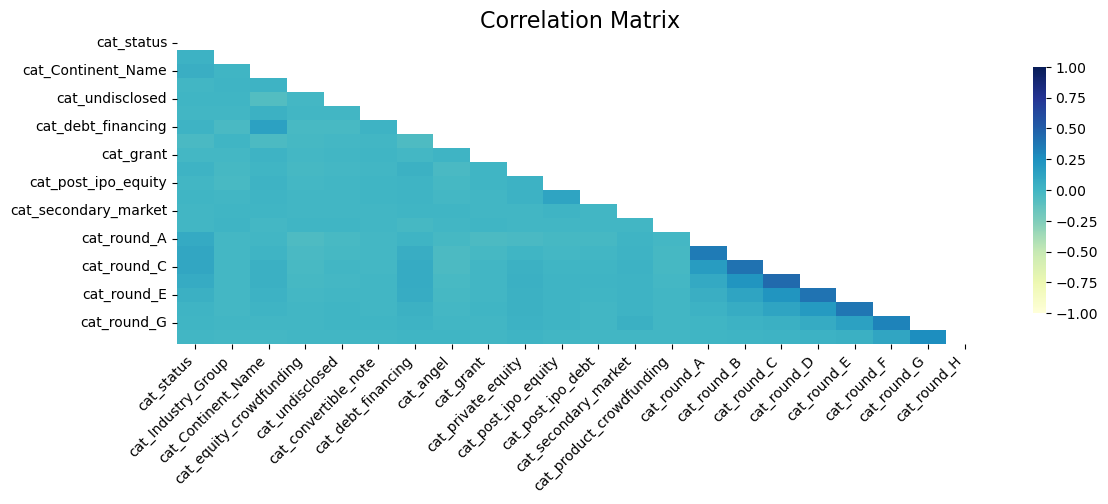

In [27]:
# #creating correlation graph
 
corr_df3 = df3.corr() 

mask = np.triu(np.ones_like(corr_df3, dtype=bool)) 

plt.figure(figsize=(13, 4))
sns.heatmap(corr_df3, mask=mask, cmap='YlGnBu', annot= True, fmt= ".2f", vmin=-1, vmax=1, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()



In [28]:
df4 = df3[['cat_status', 'cat_Industry_Group', 'cat_Continent_Name',
       'cat_funding_rounds', 'cat_diff_funding_year', 'cat_total_investment', 'cat_venture', 'cat_seed', 'cat_debt_financing', 'cat_angel',
       'cat_private_equity', 'cat_round_A', 'cat_round_B', 'cat_round_C', 'cat_round_D', 'cat_round_E', 'cat_round_F']] # selecting the columns with most correlation with the predictor 
      

34973 / ( 2146+4973+34973 )

#df4.groupby('cat_status')['cat_status'].count()

df4.head(10)


,cat_status,cat_Industry_Group,cat_Continent_Name,cat_funding_rounds,cat_diff_funding_year,cat_total_investment,cat_venture,cat_seed,cat_debt_financing,cat_angel,cat_private_equity,cat_round_A,cat_round_B,cat_round_C,cat_round_D,cat_round_E,cat_round_F
0,2,11,4,0,0,2,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,19,4,0,0,2,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,11,2,0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,9,2,0,0,2,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,42,4,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,1,6,0,0,2,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1,38,4,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1,19,1,0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1,7,6,0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1,38,4,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Dataframe 2 : Binary Predictor - Drop 'operating' rows 

Below, we construct dataframe that drops all the columns with an 'operating' (or '1') value under 'cat_status'. This allows the model to make more precise predictions about whether the company will close or be aquired since the predictions are now binary options - statistically this is intuitive as it is mroe proabble to make an precise prediction between two choices vs three choices. Notice, from above that more than 80% of the data contains 'operating' values. Hence, the model makes more accurate predictions (see the accuracy scores in the calssification reports below for the Multi-class dataframe) overall on the complete dataset because there are a larger amount of data for the model training.

/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_56474/4241228297.py:9: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_df5 = df5.corr() # correlation matrix
/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


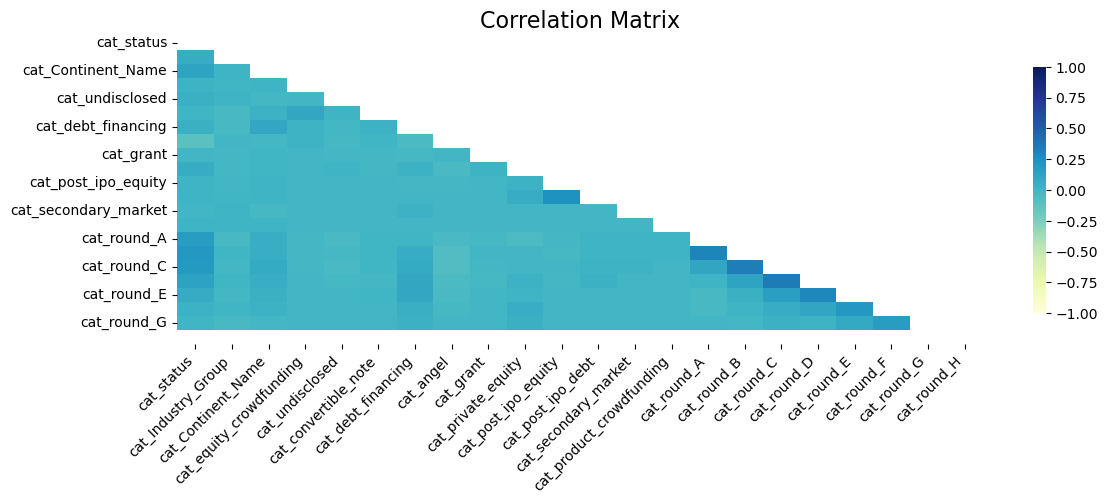

In [30]:

df5 = df3.copy()
df5.drop(df5.index[df5['cat_status'] == 1], inplace = True)
df5 = df5.replace({'cat_status':2},1) # only 0 and 1, 0 means closed and 1 means acquired 

# #we can remove cat_equity_crowdfunding, cat_undisclosed, cat_convertible_note, cat_grant , cat_post_ipo_equity, cat_post_ipo_debt, cat_secondary_market, cat_product_crowdfunding, cat_round_G, cat_round_H. This is the same as the other dataframe
# #venture and investment is highly correlated. Also high correlation between the round and the round after it. 

corr_df5 = df5.corr() # correlation matrix
mask2 = np.triu(np.ones_like(corr_df5, dtype=bool)) #  mask for the upper triangle

plt.figure(figsize=(13, 4))
sns.heatmap(corr_df5, mask=mask2, cmap='YlGnBu', annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show() 



In [31]:
df5 = df5[['cat_status', 'cat_Industry_Group', 'cat_Continent_Name',
       'cat_funding_rounds', 'cat_diff_funding_year', 'cat_total_investment', 'cat_venture', 'cat_seed', 'cat_debt_financing', 'cat_angel',
       'cat_private_equity', 'cat_round_A',
       'cat_round_B', 'cat_round_C', 'cat_round_D', 'cat_round_E',
       'cat_round_F']] # selecting the columns we need based on the correlation matrix

#df4.shape

# Models

We used two different types of models on the data to understand which model would be the best. We have tested with both multi-class and binary classification models. For multi-class models, we were trying to predict for closed, acquired and operating companies. For binary classification models, we tried to predict for closed and acquired companies only. 

## Model 1: Decision Tree

Decision Tree is a flow-chart like tree structure where the internal mode is considered as a feature and the branches are considered as a decision rule. It learns to partition on the basis of the attribute value. 

## Decision Tree: Multi-Class Classification

In [32]:
#46 sec

from snowflake.ml.modeling.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

df4 = session.write_pandas(df4, "df4", auto_create_table=True, quote_identifiers=False) #switch to snowpark dataframe

input_cols = [
    'CAT_INDUSTRY_GROUP', 'CAT_CONTINENT_NAME', 'CAT_FUNDING_ROUNDS', 'CAT_DIFF_FUNDING_YEAR', 'CAT_TOTAL_INVESTMENT', 'CAT_VENTURE', 
    'CAT_SEED', 'CAT_DEBT_FINANCING', 'CAT_ANGEL', 'CAT_PRIVATE_EQUITY', 'CAT_ROUND_A', 'CAT_ROUND_B', 'CAT_ROUND_C', 'CAT_ROUND_D', 
    'CAT_ROUND_E', 'CAT_ROUND_F'
]

train_df, test_df = df4.random_split(weights=[0.8, 0.2], seed=0)

clf = DecisionTreeClassifier(
    input_cols=input_cols, 
    label_cols=['CAT_STATUS'],
    output_cols=['PREDICTION']
)
clf = clf.fit(train_df)

#PREDICTIONS

test_preds = clf.predict(test_df)
train_preds = clf.predict(train_df)

test_pred_values = test_preds.to_pandas()['PREDICTION'] #for METRICS
train_pred_values = train_preds.to_pandas()['PREDICTION']

Y_test = test_df.to_pandas()[['CAT_STATUS']]
Y_train = train_df.to_pandas()[['CAT_STATUS']]


#METRICS

test_accuracy = accuracy_score(Y_test, test_pred_values)
train_accuracy = accuracy_score(Y_train, train_pred_values)
generalization_gap = abs(test_accuracy - train_accuracy)

acc_clf_multi = accuracy_score(Y_test, test_pred_values) ## for model registration


#  accuracy scores and classification report
print(f'Test data accuracy: {test_accuracy}')
print(f'Train data accuracy: {train_accuracy}')
print(f'Generalization gap: {generalization_gap}')

print('\nClassification Report – Multi-Class Default\n')
print(classification_report(Y_test, test_pred_values, target_names=['Closed', 'Operating', 'Acquired']))



KeyboardInterrupt: 

In [ ]:
#44 sec - RUN TIME

### Hyper parameter tuning

from snowflake.ml.modeling.model_selection import GridSearchCV
from snowflake.ml.modeling.tree import DecisionTreeClassifier


param_dict = {
    "criterion": ['gini', 'entropy'],
    "max_depth": [1, 2, 3, 4 ],
    "min_samples_split": [2, 3, 4], 
    "min_samples_leaf": [1, 2, 3]
}


decision_tree = DecisionTreeClassifier()

# Create the GridSearchCV object with Snowflake
grid = GridSearchCV(estimator=decision_tree,
                    param_grid=param_dict,
                    cv=3,  # cross validation method
                    verbose=1,
                    n_jobs=-1,
                    input_cols= ['CAT_INDUSTRY_GROUP','CAT_CONTINENT_NAME','CAT_FUNDING_ROUNDS','CAT_DIFF_FUNDING_YEAR','CAT_TOTAL_INVESTMENT','CAT_VENTURE','CAT_SEED','CAT_DEBT_FINANCING','CAT_ANGEL','CAT_PRIVATE_EQUITY','CAT_ROUND_A','CAT_ROUND_B','CAT_ROUND_C','CAT_ROUND_D','CAT_ROUND_E','CAT_ROUND_F'],  # specifying the input columns
                    label_cols= ['CAT_STATUS'],
                    output_cols = ['PREDICTION']  )  # specifying the label column


grid.fit(train_df)

print(grid.to_sklearn().best_params_, '\n')
# grid.to_sklearn().cv_results_


test_preds = grid.predict(test_df)
train_preds = grid.predict(train_df)


#PREDICTIONS

test_pred_values = test_preds.to_pandas()['PREDICTION'] #for METRICS
train_pred_values = train_preds.to_pandas()['PREDICTION']

Y_test = test_df.to_pandas()[['CAT_STATUS']]
Y_train = train_df.to_pandas()[['CAT_STATUS']]


#METRICS

test_accuracy = accuracy_score(Y_test, test_pred_values)
train_accuracy = accuracy_score(Y_train, train_pred_values)
generalization_gap = abs(test_accuracy - train_accuracy)

acc_clf_multi_tune = accuracy_score(Y_test, test_pred_values) ## for model registration


#  accuracy scores and classification report
print(f'Test data accuracy: {test_accuracy}')
print(f'Train data accuracy: {train_accuracy}')
print(f'Generalization gap: {generalization_gap}')

print('\nClassification Report – Multi-Class Default\n')
print(classification_report(Y_test, test_pred_values, target_names=['Closed', 'Operating', 'Acquired']))




##feature importance dataframe

best_estimator = grid.to_sklearn().best_estimator_
feature_importances = best_estimator.feature_importances_

feat_imp_dict = dict(zip(input_cols, feature_importances))
feat_imp = pd.DataFrame.from_dict(feat_imp_dict, orient='index', columns=['Feature Importance'])

feat_imp.sort_values(by=['Feature Importance'], ascending=False, inplace=True)
print(feat_imp.head(5))




{'criterion': 'gini', 'max_depth': 1, 'min_samples_leaf': 1, 'min_samples_split': 2} 

Test data accuracy: 0.8587347391786904
Train data accuracy: 0.8588236418549527
Generalization gap: 8.890267626238124e-05

Classification Report – Multi-Class Default

              precision    recall  f1-score   support

      Closed       0.00      0.00      0.00      9521
   Operating       0.86      1.00      0.92    135401
    Acquired       0.00      0.00      0.00     12753

    accuracy                           0.86    157675
   macro avg       0.29      0.33      0.31    157675
weighted avg       0.74      0.86      0.79    157675

                       Feature Importance
CAT_VENTURE                           1.0
CAT_INDUSTRY_GROUP                    0.0
CAT_CONTINENT_NAME                    0.0
CAT_FUNDING_ROUNDS                    0.0
CAT_DIFF_FUNDING_YEAR                 0.0


/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

In [1]:
## LOGGING MODELS        ###this saves the model into snowflake under 'Models'


from snowflake.ml._internal.utils import identifier
from snowflake.ml.registry import Registry


#1 DEfault Model 


db = identifier._get_unescaped_name(session.get_current_database())
schema = identifier._get_unescaped_name(session.get_current_schema())

native_registry = Registry(session=session, database_name=db, schema_name=schema)

#native_registry.delete_model("VC_Decision_Tree_Multiclass") #*#*#* to delete model 


model_ver = native_registry.log_model(
    model=clf,
    model_name="VC_Decision_Tree_Multiclass",
    version_name='V0_Default',
    metrics= {"Accuracy" : acc_clf_multi},
    sample_input_data= train_df ,
)

#2 Tuned Model 


model_ver = native_registry.log_model(
    model=best_estimator,
    model_name="VC_Decision_Tree_Multiclass",
    version_name='V1_Tuned',
    metrics= {"Accuracy" : acc_clfB_tune},
    sample_input_data= train_df ,
)



## Decision Tree: Binary Classification

In [ ]:
#22 sec


df5 = session.write_pandas(df5, "df5", auto_create_table=True, quote_identifiers=False) #switch to snowpark dataframe

train_df2, test_df2 = df5.random_split(weights=[0.8, 0.2], seed=0)


clfB = DecisionTreeClassifier(
    input_cols=input_cols, 
    label_cols=['CAT_STATUS'],
    output_cols=['PREDICTION']
)
clfB = clfB.fit(train_df2)

#PREDICTIONS

test_preds = clfB.predict(test_df2)
train_preds = clfB.predict(train_df2)

test_pred_values = test_preds.to_pandas()['PREDICTION'] #for METRICS
train_pred_values = train_preds.to_pandas()['PREDICTION']

Y_test = test_df2.to_pandas()[['CAT_STATUS']]
Y_train = train_df2.to_pandas()[['CAT_STATUS']]


#METRICS

test_accuracy = accuracy_score(Y_test, test_pred_values)
train_accuracy = accuracy_score(Y_train, train_pred_values)
generalization_gap = abs(test_accuracy - train_accuracy)

acc_clfB = accuracy_score(Y_test, test_pred_values) ## for model registration


#  accuracy scores and classification report
print(f'Test data accuracy: {test_accuracy}')
print(f'Train data accuracy: {train_accuracy}')
print(f'Generalization gap: {generalization_gap}')

print('\nClassification Report – Binary-Class Default\n')
print(classification_report(Y_test, test_pred_values, target_names=['Closed', 'Acquired']))




/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/site-packages/snowflake/snowpark/session.py:2182: UserWarning: Pandas Dataframe has non-standard index of type <class 'pandas.core.indexes.numeric.Int64Index'> which will not be written. Consider changing the index to pd.RangeIndex(start=0,...,step=1) or call reset_index() to keep index as column(s)
  success, nchunks, nrows, ci_output = write_pandas(


Test data accuracy: 0.5226568265682657
Train data accuracy: 0.53008049441117
Generalization gap: 0.007423667842904269

Classification Report – Binary-Class Default

              precision    recall  f1-score   support

      Closed       0.39      0.38      0.38      2667
    Acquired       0.60      0.62      0.61      4108

    accuracy                           0.52      6775
   macro avg       0.50      0.50      0.50      6775
weighted avg       0.52      0.52      0.52      6775



In [ ]:
#3.20 min


### Hyper parameter tuning

#*#*# DT deos not preform well here but the RandomForest preforms well for Bianry class


from snowflake.ml.modeling.model_selection import GridSearchCV
from snowflake.ml.modeling.tree import DecisionTreeClassifier


param_dict = {
    "criterion": ['gini', 'entropy'],
    "max_depth": [1, 2, 3, 4 ,5,6,7,8,9,10,20,30],
    "min_samples_split": [2, 3, 4,5,6,7,20,30,50,70,80], 
    "min_samples_leaf": [1, 2, 3,4,5,6,7,8,20,30,40,50,70]
}

decision_tree = DecisionTreeClassifier()


grid2 = GridSearchCV(estimator=decision_tree,
                    param_grid=param_dict,
                    cv=3,  # cross validation method
                    verbose=1,
                    n_jobs=-1,
                    input_cols= ['CAT_INDUSTRY_GROUP','CAT_CONTINENT_NAME','CAT_FUNDING_ROUNDS','CAT_DIFF_FUNDING_YEAR','CAT_TOTAL_INVESTMENT','CAT_VENTURE','CAT_SEED','CAT_DEBT_FINANCING','CAT_ANGEL','CAT_PRIVATE_EQUITY','CAT_ROUND_A','CAT_ROUND_B','CAT_ROUND_C','CAT_ROUND_D','CAT_ROUND_E','CAT_ROUND_F'],  # specifying the input columns
                    label_cols= ['CAT_STATUS'],
                    output_cols = ['PREDICTION']  )  # specifying the label column


grid2.fit(train_df2)

print(grid2.to_sklearn().best_params_, '\n')
# grid.to_sklearn().cv_results_


test_preds = grid2.predict(test_df2)
train_preds = grid2.predict(train_df2)


#PREDICTIONS

test_pred_values = test_preds.to_pandas()['PREDICTION'] #for METRICS
train_pred_values = train_preds.to_pandas()['PREDICTION']

Y_test = test_df2.to_pandas()[['CAT_STATUS']]
Y_train = train_df2.to_pandas()[['CAT_STATUS']]


#METRICS

test_accuracy = accuracy_score(Y_test, test_pred_values)
train_accuracy = accuracy_score(Y_train, train_pred_values)
generalization_gap = abs(test_accuracy - train_accuracy)

acc_clfB_tune = accuracy_score(Y_test, test_pred_values) ## for model registration


#  accuracy scores and classification report
print(f'Test data accuracy: {test_accuracy}')
print(f'Train data accuracy: {train_accuracy}')
print(f'Generalization gap: {generalization_gap}')

print('\nClassification Report – Binary-Class Default\n')
print(classification_report(Y_test, test_pred_values, target_names=['Closed', 'Acquired']))


##feature importance dataframe

best_estimator = grid.to_sklearn().best_estimator_
feature_importances = best_estimator.feature_importances_

feat_imp_dict = dict(zip(input_cols, feature_importances))
feat_imp = pd.DataFrame.from_dict(feat_imp_dict, orient='index', columns=['Feature Importance'])

feat_imp.sort_values(by=['Feature Importance'], ascending=False, inplace=True)
print(feat_imp.head(5))





{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 70} 

Test data accuracy: 0.5200356188780053
Train data accuracy: 0.5177142857142857
Generalization gap: 0.00232133316371963

Classification Report – Binary-Class Default

              precision    recall  f1-score   support

      Closed       0.38      0.38      0.38       439
    Acquired       0.61      0.61      0.61       684

    accuracy                           0.52      1123
   macro avg       0.50      0.50      0.50      1123
weighted avg       0.52      0.52      0.52      1123

                      Feature Importance
CAT_TOTAL_INVESTMENT            0.732839
CAT_INDUSTRY_GROUP              0.068482
CAT_CONTINENT_NAME              0.046542
CAT_ROUND_A                     0.032686
CAT_FUNDING_ROUNDS              0.032024


In [ ]:
# LOGGING MODELS        ###this saves the model into snowflake under 'Models'


#1 DEfault Model 


db = identifier._get_unescaped_name(session.get_current_database())
schema = identifier._get_unescaped_name(session.get_current_schema())

native_registry = Registry(session=session, database_name=db, schema_name=schema)

#native_registry.delete_model("VC_Decision_Tree_Multiclass")

model_ver = native_registry.log_model(
    model=clfB,
    model_name="VC_Decision_Tree_Binaryclass",
    version_name='V0_Default',
    metrics= {"Accuracy" : acc_clfB},
    sample_input_data= train_df ,
)

#2 Tuned Model 


model_ver = native_registry.log_model(
    model=best_estimator,
    model_name="VC_Decision_Tree_Binaryclass",
    version_name='V1_Tuned',
    metrics= {"Accuracy" : acc_clfB_tune},
    sample_input_data= train_df ,
)



/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/contextlib.py:135: UserWarning: `relax_version` is not set and therefore defaulted to True. Dependency version constraints relaxed from ==x.y.z to >=x.y, <(x+1). To use specific dependency versions for compatibility, reproducibility, etc., set `options={'relax_version': False}` when logging the model.
  return next(self.gen)
/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/site-packages/snowflake/ml/model/model_signature.py:69: UserWarning: The sample input has 121413 rows, thus a truncation happened before inferring signature. This might cause inaccurate signature inference. If that happens, consider specifying signature manually.
  warnings.warn(
/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/site-packages/sklearn/tree/_classes.py:1035: RuntimeWarning: divide by zero encountered in log
  return np.log(proba)
/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/contextlib.py:135: UserWarning: `relax_version` is

The accurate rate came up to be 0.69 and it was good at predicting for both closed and acquired companies.

According to this model, total investment, funding rounds, industry group, continent name were important features in understanding if a company will be successful or not. The model shows that total investment is very important and if it is less then the company is likely to be closed.

# Model 2: Random Forest

Random forest consists of a large number of individual decision trees that operate on ensemble. Ensemble method means that multiple models are generated and combined to solve the problem. For Random Forest, each individual tree in a random forest spits out a class prediction and the class with the most votes is the model’s prediction

## Random Forest: Multi-Class Cassification

In [ ]:
#2.21 min


from snowflake.ml.modeling.ensemble import RandomForestClassifier
from snowflake.ml.modeling.model_selection import RandomizedSearchCV

from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# df4 = session.write_pandas(df4, "df4", auto_create_table=True, quote_identifiers=False)  # switch to Snowpark DataFrame


input_cols = [
    'CAT_INDUSTRY_GROUP', 'CAT_CONTINENT_NAME', 'CAT_FUNDING_ROUNDS', 'CAT_DIFF_FUNDING_YEAR', 'CAT_TOTAL_INVESTMENT', 'CAT_VENTURE', 
    'CAT_SEED', 'CAT_DEBT_FINANCING', 'CAT_ANGEL', 'CAT_PRIVATE_EQUITY', 'CAT_ROUND_A', 'CAT_ROUND_B', 'CAT_ROUND_C', 'CAT_ROUND_D', 
    'CAT_ROUND_E', 'CAT_ROUND_F'
]


train_df, test_df = df4.random_split(weights=[0.8, 0.2], seed=0)


clfR = RandomForestClassifier(
    input_cols=input_cols, 
    label_cols=['CAT_STATUS'],
    output_cols=['PREDICTION'],
    random_state=42
)
clfR = clfR.fit(train_df)

# PREDICTIONS

test_preds = clfR.predict(test_df)
train_preds = clfR.predict(train_df)


test_pred_values = test_preds.to_pandas()['PREDICTION']  # for METRICS
train_pred_values = train_preds.to_pandas()['PREDICTION']


Y_test = test_df.to_pandas()['CAT_STATUS']
Y_train = train_df.to_pandas()['CAT_STATUS']

# METRICS

test_accuracy = accuracy_score(Y_test, test_pred_values)
train_accuracy = accuracy_score(Y_train, train_pred_values)
generalization_gap = abs(test_accuracy - train_accuracy)

#  accuracy scores and classification report
print(f'Test data accuracy: {test_accuracy}')
print(f'Train data accuracy: {train_accuracy}')
print(f'Generalization gap: {generalization_gap}')

print('\nClassification Report – Multi-Class Default\n')
print(classification_report(Y_test, test_pred_values, target_names=['Closed', 'Operating', 'Acquired']))



Test data accuracy: 0.8279296126895433
Train data accuracy: 0.8301464923400913
Generalization gap: 0.0022168796505479538

Classification Report – Multi-Class Default

              precision    recall  f1-score   support

      Closed       0.06      0.01      0.02      8230
   Operating       0.86      0.96      0.91    114073
    Acquired       0.08      0.03      0.04     10846

    accuracy                           0.83    133149
   macro avg       0.33      0.33      0.32    133149
weighted avg       0.74      0.83      0.78    133149



In [37]:
#24 min

from snowflake.ml.modeling.ensemble import RandomForestClassifier
from snowflake.ml.modeling.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

#df4 = session.write_pandas(df4, "df4", auto_create_table=True, quote_identifiers=False)  # switch to Snowpark DataFrame

input_cols = ['CAT_INDUSTRY_GROUP', 'CAT_CONTINENT_NAME', 'CAT_FUNDING_ROUNDS', 'CAT_DIFF_FUNDING_YEAR', 'CAT_TOTAL_INVESTMENT', 'CAT_VENTURE', 
    'CAT_SEED', 'CAT_DEBT_FINANCING', 'CAT_ANGEL', 'CAT_PRIVATE_EQUITY', 'CAT_ROUND_A', 'CAT_ROUND_B', 'CAT_ROUND_C', 'CAT_ROUND_D', 
    'CAT_ROUND_E', 'CAT_ROUND_F'
]

train_df, test_df = df4.random_split(weights=[0.8, 0.2], seed=0)

param_dist = {
    'n_estimators': np.arange(10, 200, 60),
    'max_depth': [None] + list(np.arange(1, 6,2)),
    'min_samples_split': np.arange(2, 60,20),
    'min_samples_leaf': np.arange(1, 60,30),
    'bootstrap': [True, False]
}

clfR = RandomForestClassifier(
    input_cols=input_cols, 
    label_cols=['CAT_STATUS'],
    output_cols=['PREDICTION'],
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=clfR,
    param_distributions=param_dist,
    n_iter=100,  
    cv=3,        
    verbose=1,
    n_jobs=-1,
    input_cols=input_cols, 
    label_cols=['CAT_STATUS'],
    output_cols=['PREDICTION'],
    random_state=42
)



random_search.fit(train_df)

print(random_search.to_sklearn().best_params_, '\n')

best_estimator = random_search.to_sklearn().best_estimator_

test_preds = random_search.predict(test_df)
train_preds = random_search.predict(train_df)

test_pred_values = test_preds.to_pandas()['PREDICTION']  # for METRICS
train_pred_values = train_preds.to_pandas()['PREDICTION']

#  actual values to pandas
Y_test = test_df.to_pandas()['CAT_STATUS']
Y_train = train_df.to_pandas()['CAT_STATUS']



# METRICS

test_accuracy = accuracy_score(Y_test, test_pred_values)
train_accuracy = accuracy_score(Y_train, train_pred_values)
generalization_gap = abs(test_accuracy - train_accuracy)

#  accuracy scores and classification report
print(f'Test data accuracy: {test_accuracy}')
print(f'Train data accuracy: {train_accuracy}')
print(f'Generalization gap: {generalization_gap}')

print('\nClassification Report – Multi-Class Default\n')
print(classification_report(Y_test, test_pred_values, target_names=['Closed', 'Operating', 'Acquired']))

feature_importances = best_estimator.feature_importances_

#   feature importances
feat_imp_dict = dict(zip(input_cols, feature_importances))
feat_imp = pd.DataFrame.from_dict(feat_imp_dict, orient='index', columns=['Feature Importance'])

feat_imp.sort_values(by=['Feature Importance'], ascending=False, inplace=True)
print(feat_imp.head(5))



## Random Forest: Binary Classification

In [ ]:
#28 sec

from snowflake.ml.modeling.ensemble import RandomForestClassifier
from snowflake.ml.modeling.model_selection import RandomizedSearchCV

from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Assuming df4 is already a Snowpark DataFrame
# df5 = session.write_pandas(df5, "df5", auto_create_table=True, quote_identifiers=False)  # switch to Snowpark DataFrame


input_cols = [
    'CAT_INDUSTRY_GROUP', 'CAT_CONTINENT_NAME', 'CAT_FUNDING_ROUNDS', 'CAT_DIFF_FUNDING_YEAR', 'CAT_TOTAL_INVESTMENT', 'CAT_VENTURE', 
    'CAT_SEED', 'CAT_DEBT_FINANCING', 'CAT_ANGEL', 'CAT_PRIVATE_EQUITY', 'CAT_ROUND_A', 'CAT_ROUND_B', 'CAT_ROUND_C', 'CAT_ROUND_D', 
    'CAT_ROUND_E', 'CAT_ROUND_F'
]


train_df, test_df = df5.random_split(weights=[0.8, 0.2], seed=0)


clfRB = RandomForestClassifier(
    input_cols=input_cols, 
    label_cols=['CAT_STATUS'],
    output_cols=['PREDICTION'],
    random_state=42
)
clfR = clfRB.fit(train_df)

# PREDICTIONS

test_preds = clfRB.predict(test_df)
train_preds = clfRB.predict(train_df)


test_pred_values = test_preds.to_pandas()['PREDICTION']  # for METRICS
train_pred_values = train_preds.to_pandas()['PREDICTION']


Y_test = test_df.to_pandas()['CAT_STATUS']
Y_train = train_df.to_pandas()['CAT_STATUS']

# METRICS

test_accuracy = accuracy_score(Y_test, test_pred_values)
train_accuracy = accuracy_score(Y_train, train_pred_values)
generalization_gap = abs(test_accuracy - train_accuracy)

#  accuracy scores and classification report
print(f'Test data accuracy: {test_accuracy}')
print(f'Train data accuracy: {train_accuracy}')
print(f'Generalization gap: {generalization_gap}')

print('\nClassification Report – Multi-Class Default\n')
print(classification_report(Y_test, test_pred_values, target_names=['Closed', 'Acquired']))



/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/site-packages/snowflake/snowpark/session.py:2182: UserWarning: Pandas Dataframe has non-standard index of type <class 'pandas.core.indexes.numeric.Int64Index'> which will not be written. Consider changing the index to pd.RangeIndex(start=0,...,step=1) or call reset_index() to keep index as column(s)
  success, nchunks, nrows, ci_output = write_pandas(


Test data accuracy: 0.5291703835860838
Train data accuracy: 0.5307288096870002
Generalization gap: 0.001558426100916388

Classification Report – Multi-Class Default

              precision    recall  f1-score   support

      Closed       0.40      0.37      0.38      2215
    Acquired       0.61      0.63      0.62      3390

    accuracy                           0.53      5605
   macro avg       0.50      0.50      0.50      5605
weighted avg       0.52      0.53      0.53      5605



In [36]:
# 1.17 min

#*#*#* DOES NOT SEEM TO PREFORM WELL WITH SNOWFLAKE MODEL , same with the sklearn ml model without tuning


from snowflake.ml.modeling.ensemble import RandomForestClassifier
from snowflake.ml.modeling.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Assuming df5 is already a Snowpark DataFrame
# df5 = session.write_pandas(df5, "df5", auto_create_table=True, quote_identifiers=False)  # switch to Snowpark DataFrame

input_cols = [
    'CAT_INDUSTRY_GROUP', 'CAT_CONTINENT_NAME', 'CAT_FUNDING_ROUNDS', 'CAT_DIFF_FUNDING_YEAR', 'CAT_TOTAL_INVESTMENT', 'CAT_VENTURE', 
    'CAT_SEED', 'CAT_DEBT_FINANCING', 'CAT_ANGEL', 'CAT_PRIVATE_EQUITY', 'CAT_ROUND_A', 'CAT_ROUND_B', 'CAT_ROUND_C', 'CAT_ROUND_D', 
    'CAT_ROUND_E', 'CAT_ROUND_F'
]


train_df, test_df = df5.random_split(weights=[0.8, 0.2], seed=0)

param_dist = {
    'n_estimators': np.arange(10, 200, step=10),
    'max_depth': [None] + list(np.arange(1, 20)),
    'min_samples_split': np.arange(2, 11),
    'min_samples_leaf': np.arange(1, 11),
    'bootstrap': [True, False]
}

clfRB2 = RandomForestClassifier()

random_search = RandomizedSearchCV(
    estimator=clfRB2,
    param_distributions=param_dist,
    n_iter=100,  
    cv=3,        
    verbose=1,
    n_jobs=-1,
    random_state=0,
    input_cols=input_cols,
    label_cols=['CAT_STATUS'],
    output_cols=['PREDICTION']
)

random_search.fit(train_df)

print(random_search.to_sklearn().best_params_, '\n')

best_estimator = random_search.to_sklearn().best_estimator_
test_preds = random_search.predict(test_df)
train_preds = random_search.predict(train_df)

test_pred_values = test_preds.to_pandas()['PREDICTION']  # for METRICS
train_pred_values = train_preds.to_pandas()['PREDICTION']

Y_test = test_df.to_pandas()[['CAT_STATUS']]
Y_train = train_df.to_pandas()[['CAT_STATUS']]

# METRICS

test_accuracy = accuracy_score(Y_test, test_pred_values)
train_accuracy = accuracy_score(Y_train, train_pred_values)
generalization_gap = abs(test_accuracy - train_accuracy)

acc_clf_multi = accuracy_score(Y_test, test_pred_values)  # for model registration

#  accuracy scores and classification report
print(f'Test data accuracy: {test_accuracy}')
print(f'Train data accuracy: {train_accuracy}')
print(f'Generalization gap: {generalization_gap}')

print('\nClassification Report – Binary-Class Default\n')
print(classification_report(Y_test, test_pred_values, target_names=['Closed', 'Acquired']))





/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/site-packages/snowflake/snowpark/session.py:2182: UserWarning: Pandas Dataframe has non-standard index of type <class 'pandas.core.indexes.numeric.Int64Index'> which will not be written. Consider changing the index to pd.RangeIndex(start=0,...,step=1) or call reset_index() to keep index as column(s)
  success, nchunks, nrows, ci_output = write_pandas(


{'n_estimators': 150, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_depth': 17, 'bootstrap': False} 

Test data accuracy: 0.516248247737989
Train data accuracy: 0.5223408074676067
Generalization gap: 0.0060925597296176415

Classification Report – Binary-Class Default

              precision    recall  f1-score   support

      Closed       0.38      0.39      0.38      3063
    Acquired       0.60      0.60      0.60      4784

    accuracy                           0.52      7847
   macro avg       0.49      0.49      0.49      7847
weighted avg       0.52      0.52      0.52      7847



In [ ]:
# 56 sec

#*#*#* ML MODEL IS SKLEARN ADN SEARCH MODEL IS SNOWPARK - PREFORMS BETTER


from snowflake.ml.modeling.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd

# Assuming df5 is already a Snowpark DataFrame
# df5 = session.write_pandas(df5, "df5", auto_create_table=True, quote_identifiers=False)  # switch to Snowpark DataFrame

input_cols = [
    'CAT_INDUSTRY_GROUP', 'CAT_CONTINENT_NAME', 'CAT_FUNDING_ROUNDS', 'CAT_DIFF_FUNDING_YEAR', 'CAT_TOTAL_INVESTMENT', 'CAT_VENTURE', 
    'CAT_SEED', 'CAT_DEBT_FINANCING', 'CAT_ANGEL', 'CAT_PRIVATE_EQUITY', 'CAT_ROUND_A', 'CAT_ROUND_B', 'CAT_ROUND_C', 'CAT_ROUND_D', 
    'CAT_ROUND_E', 'CAT_ROUND_F']

train_df, test_df = df5.random_split(weights=[0.8, 0.2], seed=0)

param_dist = {
    'n_estimators': np.arange(10, 200, step=10),
    'max_depth': [None] + list(np.arange(1, 20)),
    'min_samples_split': np.arange(2, 11),
    'min_samples_leaf': np.arange(1, 11),
    'bootstrap': [True, False]
}


clfRSK = RandomForestClassifier(random_state=0)

random_search = RandomizedSearchCV(
    estimator=clfRSK,
    param_distributions=param_dist,
    n_iter=100,  
    cv=3,        
    verbose=1,
    n_jobs=-1,
    random_state=0,
    input_cols=input_cols,
    label_cols=['CAT_STATUS'],
    output_cols=['PREDICTION']
)


random_search.fit(train_df)


print(random_search.to_sklearn().best_params_, '\n')


best_estimator = random_search.to_sklearn().best_estimator_
test_preds = best_estimator.predict(test_df.to_pandas()[input_cols])
train_preds = best_estimator.predict(train_df.to_pandas()[input_cols])

Y_test = test_df.to_pandas()[['CAT_STATUS']]
Y_train = train_df.to_pandas()[['CAT_STATUS']]

# METRICS

test_accuracy = accuracy_score(Y_test, test_preds)
train_accuracy = accuracy_score(Y_train, train_preds)
generalization_gap = abs(test_accuracy - train_accuracy)

acc_clf_multi = accuracy_score(Y_test, test_preds)  # for model registration

#  accuracy scores and classification report
print(f'Test data accuracy: {test_accuracy}')
print(f'Train data accuracy: {train_accuracy}')
print(f'Generalization gap: {generalization_gap}')

print('\nClassification Report – Binary-Class Default\n')
print(classification_report(Y_test, test_preds, target_names=['Closed', 'Acquired']))

feature_importances = best_estimator.feature_importances_


feat_imp_dict = dict(zip(input_cols, feature_importances))
feat_imp = pd.DataFrame.from_dict(feat_imp_dict, orient='index', columns=['Feature Importance'])

#  by feature importance and display the top 5 features
feat_imp.sort_values(by=['Feature Importance'], ascending=False, inplace=True)
print(feat_imp.head(5))



/Users/cs/anaconda3/envs/snowpark-ml-hol/lib/python3.10/site-packages/snowflake/snowpark/session.py:2182: UserWarning: Pandas Dataframe has non-standard index of type <class 'pandas.core.indexes.numeric.Int64Index'> which will not be written. Consider changing the index to pd.RangeIndex(start=0,...,step=1) or call reset_index() to keep index as column(s)
  success, nchunks, nrows, ci_output = write_pandas(


{'n_estimators': 150, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_depth': 17, 'bootstrap': False} 

Test data accuracy: 0.7785920497446147
Train data accuracy: 0.8136542969866774
Generalization gap: 0.03506224724206264

Classification Report – Binary-Class Default

              precision    recall  f1-score   support

      Closed       0.73      0.70      0.71      1761
    Acquired       0.81      0.83      0.82      2742

    accuracy                           0.78      4503
   macro avg       0.77      0.76      0.77      4503
weighted avg       0.78      0.78      0.78      4503

                      Feature Importance
CAT_INDUSTRY_GROUP              0.345799
CAT_TOTAL_INVESTMENT            0.194921
CAT_VENTURE                     0.095246
CAT_CONTINENT_NAME              0.075117
CAT_FUNDING_ROUNDS              0.046436


In [ ]:
# #*#* Loading our model into snowflake 

# import joblib 

# MODEL_FILE = 'model.joblib'
# joblib.dump(clf, MODEL_FILE) # we are pickling it locally first

# # You can also save the pickled object into a stage
# session.file.put(MODEL_FILE, "@VC_STAGE", overwrite=True)


[PutResult(source='model.joblib', target='model.joblib.gz', source_size=437457, target_size=60848, source_compression='NONE', target_compression='GZIP', status='UPLOADED', message='')]

In [2]:
# import pandas as pd
# from snowflake import vectorized
# from sklearn.model_selection import GridSearchCV
# from sklearn.tree import DecisionTreeClassifier

# class GridSearchHandler:
#     def __init__(self):
#         pass

#     @vectorized(input=pandas.DataFrame)
#     def end_partition(self, df: pd.DataFrame) -> pd.DataFrame:

#         param_dict = {
#             "criterion": ['gini', 'entropy'],
#             "max_depth": [1, 2, 3, 4, 5, 10, 15, 20, 30, 70, 80],
#             "min_samples_split": [2, 3, 4, 5, 10, 15, 20, 40, 70, 80],
#             "min_samples_leaf": [1, 2, 3, 4, 5, 10, 15, 20, 30, 40, 70, 80]
#         }

#         decision_tree = DecisionTreeClassifier()
#         grid = GridSearchCV(
#             decision_tree,
#             param_grid=param_dict,
#             cv=6,  
#             verbose=1,
#             n_jobs=-1  
#         )


#         X = df.drop('cat_status', axis=1)
#         y = df['cat_status']


#         grid.fit(X, y)

#         results = pd.DataFrame(grid.cv_results_)

#         return results

# GridSearchHandler.end_partition._sf_vectorized_input = pd.DataFrame


# from snowflake.snowpark import Session


# grid_search_udtf = session.udtf.register(
#     GridSearchHandler,
#     output_schema=["params", "mean_test_score", "std_test_score"],
#     input_types=[pandas.DataFrame]
# )


In [3]:
# from snowflake.snowpark.functions import udtf

# import pandas as pd
# from sklearn.model_selection import GridSearchCV, train_test_split
# from sklearn.tree import DecisionTreeClassifier

# from _snowflake import vectorized

# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)  # test and train dataset

# class handler:
#     def __init__(self):
#         pass  #  a state if necessary

#     @vectorized(input=pd.DataFrame)
#     def end_partition(self, df):
#         param_dict = {
#             "criterion": ['gini', 'entropy'],
#             "max_depth": [1, 2, 3, 4, 5, 10, 15, 20, 30, 70, 80],
#             "min_samples_split": [2, 3, 4, 5, 10, 15, 20, 40, 70, 80],
#             "min_samples_leaf": [1, 2, 3, 4, 5, 10, 15, 20, 30, 40, 70, 80]
#         }

#         decision_tree = DecisionTreeClassifier()
#         grid = GridSearchCV(
#             decision_tree,
#             param_grid=param_dict,
#             cv=6,
#             verbose=1,
#             n_jobs=-1
#         )

#         grid.fit(X_train, Y_train)

#         best_params = grid.best_params_

#         results = pd.DataFrame([best_params])

#         return results


# handler.end_partition._sf_vectorized_input = pd.DataFrame

# # test locally (not in Snowflake), create an instance and call the method
# handler_instance = handler()
# best_params_df = handler_instance.end_partition(pd.DataFrame())
# print(best_params_df)



# udf_registration.register(
#     func=my_udtf,
#     return_type = PandasDataFrameType(),
#     input_types = PandasDataFrameType(),
#     name = "my_udtf",
#     is_permanent = True,
#     replace = True,
#     stage_location ="@",  
#     )